# Convolution output size

  $$
  H_{\text{out}} =
  \left\lfloor
  \frac{H_{\text{in}} + 2P - K}{S}
  \right\rfloor + 1
  $$

  $$
  W_{\text{out}} =
  \left\lfloor
  \frac{W_{\text{in}} + 2P - K}{S}
  \right\rfloor + 1
  $$

  ### Pooling output size

  $$
  H_{\text{out}} =
  \left\lfloor
  \frac{H_{\text{in}} + 2P - K}{S}
  \right\rfloor + 1
  $$

  $$
  W_{\text{out}} =
  \left\lfloor
  \frac{W_{\text{in}} + 2P - K}{S}
  \right\rfloor + 1
  $$

  ### Flatten dimension

  $$
  \text{flatten\_dim} =
  C_{\text{out}} \cdot H_{\text{out}} \cdot
  W_{\text{out}}
  $$

  ### Minimum LogicDense output size

  $$
  \text{out\_dim}_{\min} =
  \left\lceil
  \frac{\text{in\_dim}}{\text{lut\_rank}}
  \right\rceil
  $$

  ### Valid LogicDense condition

  $$
  \text{out\_dim} \cdot \text{lut\_rank}
  \ge
  \text{in\_dim}
  $$

  ### GroupSum divisibility condition

  $$
  \text{out\_dim} \bmod \text{num\_classes} = 0
  $$


In [1]:
import os
# For exact CUDA error lines: restart the kernel, uncomment this, then run from the top.
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
from torchlogix.layers import LogicConv2d, LogicDense, OrPooling2d, GroupSum
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
class LogicNet(nn.Module):
    def __init__(self,
        num_classes=10,
        conv_num=3, 
        dense_num=4, 
        base_dense_dims = [2048, 1280, 640, 320],         
        kernel_multiplier=3, 
        k=16,
        tau=6.5,
        gauss_sigma = 1.5,
        parametrization="raw",
        forward_sampling="gumbel_soft",
        weight_init="gaussian",
        parametrization_temperature=1.0,         
    ):
        super().__init__()
        logic_kwargs = {
        "parametrization": parametrization,
        "parametrization_kwargs": {
        "forward_sampling": forward_sampling,
        "weight_init": weight_init,
        "temperature": parametrization_temperature,
       
      },
        "connections": "fixed",
        "connections_kwargs": {"init_method": "gaussian","sigma": gauss_sigma },
  }

        if conv_num < 1:
            raise ValueError("conv_num must be at least 1")
        if kernel_multiplier < 1:
            raise ValueError("kernel_multiplier must be at least 1")
        if k < 1:
            raise ValueError("k must be at least 1")
        if dense_num != len(base_dense_dims):
            raise ValueError(
                f"dense_num must be equal to len(base_dense_dims). "
                f"Got dense_num={dense_num}, "
                f"len(base_dense_dims)={len(base_dense_dims)}, "
                f"base_dense_dims={base_dense_dims}."
            )
        def conv_out_dim(size, receptive_field_size, padding, stride=1):
            return (size + 2 * padding - receptive_field_size) // stride + 1

        def pool_out_dim(size, kernel_size=2, stride=2, padding=0):
            return (size + 2 * padding - kernel_size) // stride + 1

        channels = 1
        height = 28
        width = 28
        feature_layers = []
        self.shape_trace = []
        self.sigma = gauss_sigma
        for block_idx in range(conv_num):
            receptive_field_size = 5 if block_idx == 0 else 3
            padding = 0 if block_idx == 0 else 1
            num_kernels = k * (kernel_multiplier ** block_idx)

            feature_layers.append(
                LogicConv2d(
                    in_dim=(height, width),
                    channels=channels,
                    num_kernels=num_kernels,
                    tree_depth=3,
                    receptive_field_size=receptive_field_size,
                    padding=padding,
                     **logic_kwargs,
                )
            )

            conv_height = conv_out_dim(height, receptive_field_size, padding)
            conv_width = conv_out_dim(width, receptive_field_size, padding)
            if conv_height <= 0 or conv_width <= 0:
                raise ValueError(f"conv block {block_idx + 1} produces invalid size {conv_height}x{conv_width}")

            feature_layers.append(OrPooling2d(kernel_size=2, stride=2, padding=0))

            pool_height = pool_out_dim(conv_height)
            pool_width = pool_out_dim(conv_width)
            if pool_height <= 0 or pool_width <= 0:
                raise ValueError(f"pool block {block_idx + 1} produces invalid size {pool_height}x{pool_width}")

            self.shape_trace.append(
                {
                    "block": block_idx + 1,
                    "channels": num_kernels,
                    "conv_size": (conv_height, conv_width),
                    "pool_size": (pool_height, pool_width), 
                }
            )

            channels = num_kernels
            height = pool_height
            width = pool_width

        self.features = nn.Sequential(*feature_layers)
        
        flatten_dim = channels * height * width
        layers = [nn.Flatten()]
        if  (base_dense_dims[-1]*k)% num_classes != 0:
            raise ValueError(
                f"base_dense_dims[-1]*k = {base_dense_dims[-1]*k} must be divisible by "
                f"num_classes = {num_classes} for GroupSum"
                )
        
        for dense_idx in range(dense_num):
            dense_out =k*base_dense_dims[dense_idx]
            if(dense_idx == 0):
                dense_in = flatten_dim
            
            if dense_out * 2 < dense_in:
                raise ValueError(
                    f"out_dim * 2 must be >= in_dim at dense layer {dense_idx + 1}. "
                    f"Got out_dim={dense_out}, "
                    f"in_dim={dense_in}, "
                    f"out_dim*2={dense_out * 2}, "
                    f"flatten_dim={flatten_dim}, "
                    f"shape_trace={self.shape_trace}."
                )
            layers.append(LogicDense(in_dim=dense_in, out_dim=dense_out, **logic_kwargs,))
            dense_in = dense_out        

        layers.append(GroupSum(num_classes, tau=tau))   
        self.classifier = nn.Sequential(        
            *layers
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create and use the model
model = LogicNet(num_classes=10,dense_num=3,base_dense_dims=[1280,640,320], conv_num=3, kernel_multiplier=3, k=16)
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

I0000 00:00:1778605026.637320   17907 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778605028.038702   17907 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
FORCE_CPU = False  # Change to True if CUDA kernel errors block debugging.
device = torch.device("cpu" if FORCE_CPU else "cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-1,weight_decay=0)
def load_n(loader, n):
    i = 0
    while i < n:
        for batch in loader:
            yield batch
            i+=1 
            if i == n:
                return

def evaluate(loader, train_mode=False):
    orig_mode = model.training
    model.train(train_mode)
    batch_size = 512

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    model.train(orig_mode)
    return total_loss / total, total_correct / total

num_iterations = 2500
metrics_every = 100
running_loss = 0.0
running_examples = 0
test_loss_acc = {
    "train_iteration": [],
    "test_acc_discrete": [],
    "test_loss_discrete": [],
    "test_acc_relaxed": [],
    "test_loss_relaxed": [],
}

for step, (x, y) in enumerate(load_n(train_loader, num_iterations), start=1):
    model.train()
    x, y = x.to(device), y.to(device)
  
    logits = model(x)
    loss = loss_fn(logits, y)
   
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * y.size(0)
    running_examples += y.size(0)

    if step % metrics_every == 0:
        disc_loss, disc_acc = evaluate(test_loader, train_mode=False)
        relax_loss, relax_acc = evaluate(test_loader, train_mode=True)
        train_loss = running_loss / running_examples
        test_loss_acc["train_iteration"].append(step)
        test_loss_acc["test_acc_discrete"].append(disc_acc)
        test_loss_acc["test_loss_discrete"].append(disc_loss)
        test_loss_acc["test_acc_relaxed"].append(relax_acc)
        test_loss_acc["test_loss_relaxed"].append(relax_loss)
       
        print(
             

            f"iter {step:4d} | "
            f"train_loss {train_loss:.4f} | "
            f"test_acc_d1iscrete {disc_acc:.4f} | test_loss_discrete {disc_loss:.4f} | "
            f"test_acc_relaxed {relax_acc:.4f} | test_loss_relaxed {relax_loss:.4f}"
        )

        running_loss = 0.0
        running_examples = 0


cuda

iter  100 | train_loss 2.6474 | test_acc_d1iscrete 0.1167 | test_loss_discrete 4.6186 | test_acc_relaxed 0.1090 | test_loss_relaxed 2.5289
iter  200 | train_loss 2.5159 | test_acc_d1iscrete 0.1513 | test_loss_discrete 3.4045 | test_acc_relaxed 0.1636 | test_loss_relaxed 2.2251
iter  300 | train_loss 1.3359 | test_acc_d1iscrete 0.6978 | test_loss_discrete 0.8830 | test_acc_relaxed 0.7721 | test_loss_relaxed 0.6932
iter  400 | train_loss 0.5414 | test_acc_d1iscrete 0.8474 | test_loss_discrete 0.4656 | test_acc_relaxed 0.8768 | test_loss_relaxed 0.4165
iter  500 | train_loss 0.3862 | test_acc_d1iscrete 0.8727 | test_loss_discrete 0.3934 | test_acc_relaxed 0.9015 | test_loss_relaxed 0.3330
iter  600 | train_loss 0.3280 | test_acc_d1iscrete 0.9172 | test_loss_discrete 0.2797 | test_acc_relaxed 0.9149 | test_loss_relaxed 0.2925
iter  700 | train_loss 0.2912 | test_acc_d1iscrete 0.9241 | test_loss_discrete 0.2556 | test_acc_relaxed 0.9270 | test_loss_relaxed 0.2569
iter  800 | train_los

In [ ]:
###### fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(test_loss_acc["train_iteration"], test_loss_acc["test_acc_discrete"], "--", c="b", label="Discrete")
axes[0].plot(test_loss_acc["train_iteration"], test_loss_acc["test_acc_relaxed"], "--", c="r", label="Relaxed")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Test accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(test_loss_acc["train_iteration"], test_loss_acc["test_loss_discrete"], "--", c="b", label="Discrete")
axes[1].plot(test_loss_acc["train_iteration"], test_loss_acc["test_loss_relaxed"], "--", c="r", label="Relaxed")
axes[1].set_xlabel("training iteration")
axes[1].set_ylabel("loss")
axes[1].set_title("Test loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:
image, label = test_dataset[500]

device = next(model.parameters()).device
loss_fn = nn.CrossEntropyLoss()
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

def evaluate_model(model, loader, loss_fn, device):
    was_training = model.training
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0
"""
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples +z= y.sie(0)

    model.train(was_training)
    return total_loss / total_examples, total_correct / total_examples
    
test_loss, test_acc = evaluate_model(model, test_loader, loss_fn, device)
print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_acc:.4f}")

"""

'\n    with torch.no_grad():\n        for x, y in loader:\n            x, y = x.to(device), y.to(device)\n            logits = model(x)\n            total_loss += loss_fn(logits, y).item() * y.size(0)\n            total_correct += (logits.argmax(dim=1) == y).sum().item()\n            total_examples +z= y.sie(0)\n\n    model.train(was_training)\n    return total_loss / total_examples, total_correct / total_examples\n\ntest_loss, test_acc = evaluate_model(model, test_loader, loss_fn, device)\nprint(f"test loss: {test_loss:.4f}")\nprint(f"test accuracy: {test_acc:.4f}")\n\n'

In [ ]:
device = next(model.parameters()).device
was_training = model.training
model.eval()

with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))[0].detach().cpu()
    scores = logits.numpy()

model.train(was_training)

pred = int(scores.argmax())

print("scores:", scores)
print(f"true label: {label}, predicted: {pred}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image.squeeze().numpy(), cmap="gray")
axes[0].set_title(f"input image | true={label}")
axes[0].axis("off")

axes[1].bar(range(len(scores)), scores)
axes[1].set_xticks(range(len(scores)))
axes[1].set_xlabel("digit class")
axes[1].set_ylabel("score")
axes[1].set_title(f"network output | pred={pred}")

plt.tight_layout()
plt.show()

NameError: name 'image' is not defined

In [ ]:
probabilities = torch.softmax(logits, dim=0).numpy()

print("softmax probabilities:", probabilities)

plt.figure(figsize=(8, 4))
plt.bar(range(len(probabilities)), probabilities)
plt.xticks(range(len(probabilities)))
plt.xlabel("digit class")
plt.ylabel("probability")
plt.title(f"softmax(network output) | pred={pred}")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


NameError: name 'logits' is not defined

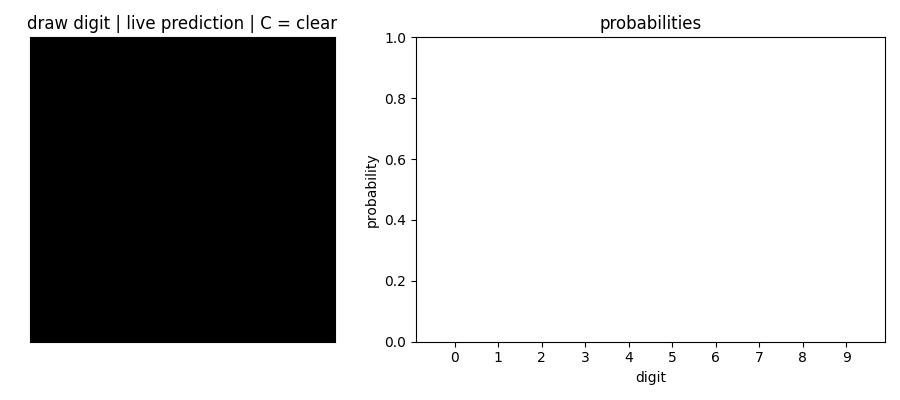

Draw on the canvas; predictions update live. Press C to clear.


In [ ]:
# 28x28 MNIST drawing canvas. Run this cell after `model` has been trained or loaded.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    get_ipython().run_line_magic("matplotlib", "inline")
    print("Interactive drawing requires ipympl. Install it in the JupyterLab environment, restart JupyterLab, then rerun this cell.")

import numpy as np
import torch
import matplotlib.pyplot as plt
import time

canvas = np.zeros((28, 28), dtype=np.float32)
brush_radius = 1.35
state = {"drawing": False, "last": None, "last_predict": 0.0}
PREDICT_INTERVAL_SECONDS = 0.08
DRAW_PREDICT_ON_CPU = False  # Change to True if the canvas prediction fails on CUDA.

fig, (ax_canvas, ax_probs) = plt.subplots(
    1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 1.4]}
)

image_artist = ax_canvas.imshow(
    canvas,
    cmap="gray",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    extent=(-0.5, 27.5, 27.5, -0.5),
)
ax_canvas.set_title("draw digit | live prediction | C = clear")
ax_canvas.set_xticks([])
ax_canvas.set_yticks([])
ax_canvas.set_xlim(-0.5, 27.5)
ax_canvas.set_ylim(27.5, -0.5)

bars = ax_probs.bar(range(10), np.zeros(10))
ax_probs.set_title("probabilities")
ax_probs.set_xlabel("digit")
ax_probs.set_ylabel("probability")
ax_probs.set_xticks(range(10))
ax_probs.set_ylim(0, 1)
prob_text = ax_probs.text(
    0.02,
    0.98,
    "",
    transform=ax_probs.transAxes,
    va="top",
    family="monospace",
    fontsize=9,
)


def _paint_pixel(x, y):
    col = int(round(x))
    row = int(round(y))

    for rr in range(max(0, row - 3), min(28, row + 4)):
        for cc in range(max(0, col - 3), min(28, col + 4)):
            distance = ((rr - y) ** 2 + (cc - x) ** 2) ** 0.5
            if distance <= brush_radius:
                canvas[rr, cc] = max(canvas[rr, cc], 1.0 - 0.35 * distance / brush_radius)


def _paint_line(start, end):
    if start is None:
        _paint_pixel(*end)
        return

    x0, y0 = start
    x1, y1 = end
    steps = int(max(abs(x1 - x0), abs(y1 - y0)) * 3) + 1
    for t in np.linspace(0, 1, steps):
        _paint_pixel(x0 + (x1 - x0) * t, y0 + (y1 - y0) * t)


def _refresh_canvas():
    image_artist.set_data(canvas)
    fig.canvas.draw_idle()


def _predict(force=False):
    if "model" not in globals():
        ax_probs.set_title("probabilities | run model cell first")
        prob_text.set_text("model is not loaded")
        fig.canvas.draw_idle()
        return

    now = time.monotonic()
    if not force and now - state["last_predict"] < PREDICT_INTERVAL_SECONDS:
        return
    state["last_predict"] = now

    if not np.any(canvas):
        for bar in bars:
            bar.set_height(0)
        ax_probs.set_title("probabilities")
        prob_text.set_text("")
        fig.canvas.draw_idle()
        return

    original_device = next(model.parameters()).device
    predict_device = torch.device("cpu") if DRAW_PREDICT_ON_CPU else original_device
    was_training = model.training

    try:
        if predict_device != original_device:
            model.to(predict_device)
        model.eval()

        x = torch.from_numpy(canvas).unsqueeze(0).unsqueeze(0).to(predict_device)
        with torch.no_grad():
            logits = model(x.float())[0].detach().cpu()
            probabilities = torch.softmax(logits, dim=0).numpy()
    finally:
        model.train(was_training)
        if predict_device != original_device:
            model.to(original_device)

    prediction = int(probabilities.argmax())
    for digit, bar in enumerate(bars):
        bar.set_height(float(probabilities[digit]))

    ax_probs.set_title(f"probabilities | pred={prediction}")
    prob_text.set_text("\n".join(f"{i}: {p:.3f}" for i, p in enumerate(probabilities)))
    fig.canvas.draw_idle()


def _clear():
    canvas.fill(0)
    state["last_predict"] = 0.0
    for bar in bars:
        bar.set_height(0)
    ax_probs.set_title("probabilities")
    prob_text.set_text("")
    _refresh_canvas()


def _on_press(event):
    if event.inaxes != ax_canvas or event.xdata is None or event.ydata is None:
        return
    state["drawing"] = True
    point = (event.xdata, event.ydata)
    state["last"] = point
    _paint_line(None, point)
    
    _refresh_canvas()
    _predict(force=True)
    

def _on_motion(event):
    if not state["drawing"] or event.inaxes != ax_canvas or event.xdata is None or event.ydata is None:
        return
    point = (event.xdata, event.ydata)
    _paint_line(state["last"], point)
    state["last"] = point
    _refresh_canvas()
    _predict()


def _on_release(event):
    state["drawing"] = False
    state["last"] = None
    _predict(force=True)


def _on_key(event):
    if event.key in ("c", "backspace", "delete"):
        _clear()


fig.canvas.mpl_connect("button_press_event", _on_press)
fig.canvas.mpl_connect("motion_notify_event", _on_motion)
fig.canvas.mpl_connect("button_release_event", _on_release)
fig.canvas.mpl_connect("key_press_event", _on_key)

plt.tight_layout()
plt.show()
print("Draw on the canvas; predictions update live. Press C to clear.")

